# Act 05: Estrategia SMA + Bollinger + RSI + MACD sobre BTC (barras de 4 horas)
**Isabela Torres Septien Uribe**

Este notebook implementa la estrategia definida en `SPEC.md` y muestra cada paso con tablas y gráficas:

1. Carga y limpieza de datos, agregación a barras de 4 horas
2. División train / test / validation
3. Cálculo de indicadores y gráficas (precio histórico y precio con indicadores)
4. Reglas de entrada (2 condiciones + cruce alcista del MACD) y señales generadas
5. Backtest orientado a eventos: cuándo entra y cuándo sale la estrategia
6. Resumen de operaciones, curva de equity y drawdown
7. Métricas, capital final y viabilidad según el Calmar ratio
8. Sensibilidad a costos, win rate teórico contra empírico, pruebas y auditoría de sesgos

**Resumen de la estrategia**

| Bloque | Regla |
|---|---|
| Entrada C1 (tendencia) | SMA_10 > SMA_100 **y** close > BB_mid |
| Entrada C2 (momentum) | MACD > señal **y** 50 < RSI_14 < 70 **y** close < BB_high |
| Disparador de entrada | MACD cruza hacia arriba su señal manteniendo las demás condiciones |
| Salida 1 | Stop-loss = entrada − 4 × ATR |
| Salida 2 | Take-profit = entrada + 3 × ATR |
| Salida 3 | Stop a break-even: al ganar 1 ATR, el stop sube al precio de entrada |
| Holding máximo | Ninguno: si no se toca SL ni TP la posición sigue abierta |
| Sizing | unidades = ρ × equity / (entrada − stop), ρ = 2 % |
| Costos (largo) | 10 bps comisión + 5 bps slippage por lado (30 bps ida y vuelta) |
| Capital inicial | $100,000 |

> **Nota:** la estrategia usa SMA_100 como filtro de tendencia y el trigger de entrada se activa con el cruce alcista del MACD sobre su señal. La frecuencia sigue siendo 4 horas y el stop se amplió a 4 ATR.


In [9]:
import subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

from src.indicators import load_bars, add_indicators
from src.strategy import Params, entry_conditions
from src.backtest import backtest, run_pipeline, with_costs
from src import metrics as M

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})
BLUE, ORANGE, AQUA, VIOLET, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#8a8984"
GOOD, BAD, WARN = "#008300", "#e34948", "#eda100"
DATA = "data/btc_project_train.csv"
P = Params()
P

Params(rho=0.02, sl_atr=4.0, tp_atr=3.0, be_atr=1.0, rsi_low=50.0, rsi_high=70.0, commission_bps=10.0, slippage_bps=5.0, initial_cash=100000.0)

## 1. Carga y limpieza de datos (barras de 5 minutos)

In [10]:
raw = pd.read_csv(DATA)
print("Filas originales:", len(raw))
display(raw.head())
nulos = raw[["Open", "High", "Low", "Close"]].isnull().sum().rename("NaN por columna")
display(nulos.to_frame())

Filas originales: 166450


,Timestamp,Gmtoffset,Datetime,Open,High,Low,Close,Volume
0,1654041600,0,2022-06-01 00:00:00,"31,803.69","31,834.98","31,803.69","31,834.98",NaN
1,1654041900,0,2022-06-01 00:05:00,"31,834.91","31,853.06","31,834.91","31,853.06",NaN
2,1654042200,0,2022-06-01 00:10:00,"31,854.18","31,854.18","31,747.34","31,747.38",NaN
3,1654042500,0,2022-06-01 00:15:00,"31,750.77","31,840.39","31,750.77","31,840.39","39,202,816.00"
4,1654042800,0,2022-06-01 00:20:00,"31,844.46","31,844.46","31,777.64","31,777.64",NaN


,NaN por columna
Open,3745
High,3745
Low,3745
Close,3745


## 2. Agregación a barras de 4 horas
Bloques de 00, 04, 08, 12, 16 y 20 h. Open = primer open del bloque, High = máximo, Low = mínimo, Close = último close. Se eliminan las filas con NaN antes de agregar.

In [11]:
FREQ = "4h"
df = load_bars(DATA, FREQ)
print(f"Barras de 4 h: {len(df):,}  |  desde {df.index[0]}  hasta {df.index[-1]}")
display(df.head(10))
display(df.describe().T)

Barras de 4 h: 3,450  |  desde 2022-06-01 00:00:00  hasta 2023-12-31 00:00:00


,open,high,low,close
datetime,,,,
2022-06-01 00:00:00,"31,803.69","31,957.29","31,634.65","31,641.48"
2022-06-01 04:00:00,"31,643.92","31,682.44","31,444.69","31,484.64"
2022-06-01 08:00:00,"31,482.88","31,671.76","31,469.00","31,566.35"
2022-06-01 12:00:00,"31,583.26","31,848.82","30,799.29","30,804.89"
2022-06-01 16:00:00,"30,786.88","30,786.88","30,028.59","30,168.81"
2022-06-01 20:00:00,"30,166.67","30,166.67","29,501.59","29,721.62"
2022-06-02 00:00:00,"29,795.88","29,871.41","29,652.71","29,735.21"
2022-06-02 04:00:00,"29,726.58","30,040.35","29,696.02","29,955.62"
2022-06-02 08:00:00,"29,954.50","30,154.05","29,881.75","30,151.47"


,count,mean,std,min,25%,50%,75%,max
open,"3,450.00","25,652.90","6,484.23","15,709.01","20,463.89","25,834.37","29,181.40","44,191.21"
high,"3,450.00","25,801.44","6,521.48","15,788.88","20,649.08","25,944.40","29,305.08","44,705.52"
low,"3,450.00","25,504.86","6,453.36","15,599.05","20,323.77","25,748.72","29,096.28","44,127.13"
close,"3,450.00","25,655.33","6,489.81","15,698.94","20,464.81","25,830.51","29,179.58","44,193.84"


## 3. División cronológica train / test / validation (60 / 20 / 20)

In [12]:
n = len(df); a, b = int(n * 0.6), int(n * 0.8)
splits = {"Train": df.iloc[:a], "Test": df.iloc[a:b], "Validation": df.iloc[b:]}
tabla_split = pd.DataFrame({k: {"Inicio": v.index[0], "Fin": v.index[-1], "Barras": len(v),
                                "Precio inicial": v["close"].iloc[0], "Precio final": v["close"].iloc[-1],
                                "Buy & hold (%)": 100 * (v["close"].iloc[-1] / v["close"].iloc[0] - 1)}
                            for k, v in splits.items()}).T
tabla_split

,Inicio,Fin,Barras,Precio inicial,Precio final,Buy & hold (%)
Train,2022-06-01 00:00:00,2023-05-15 00:00:00,2070,"31,641.48","27,259.02",-13.85
Test,2023-05-15 04:00:00,2023-09-07 00:00:00,690,"27,418.78","25,822.50",-5.82
Validation,2023-09-07 04:00:00,2023-12-31 00:00:00,690,"25,751.93","42,198.00",63.86


## 4. Gráfica 1: precio histórico de BTC

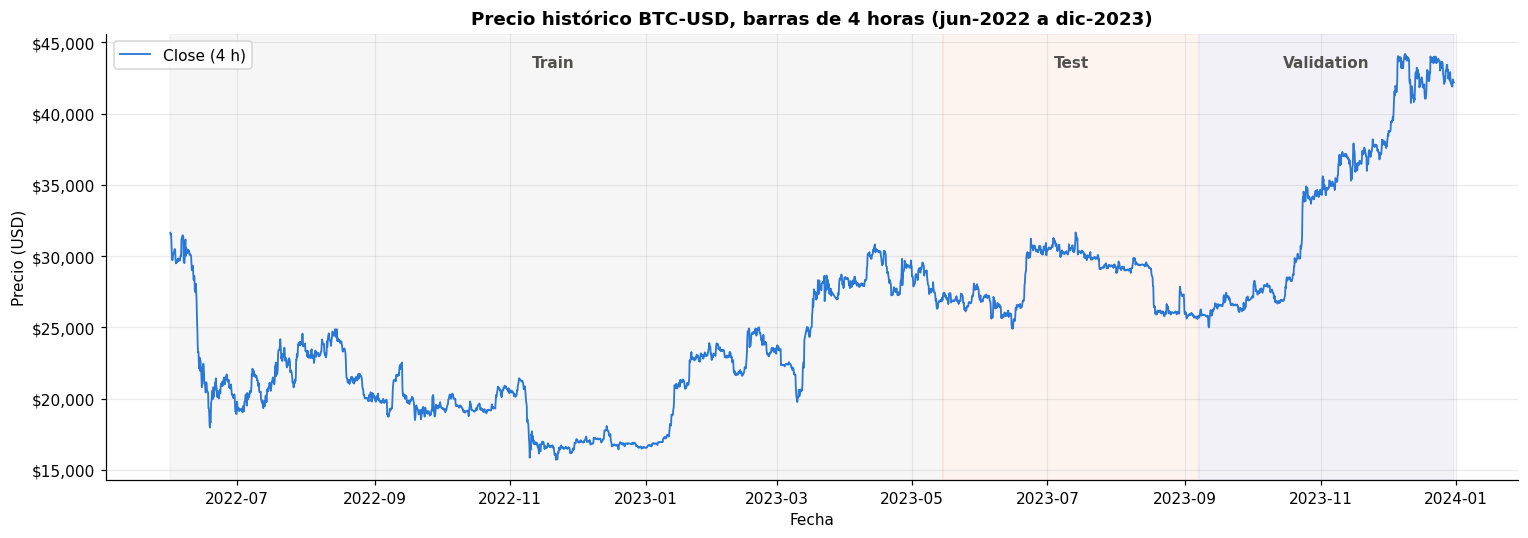

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["close"], color=BLUE, lw=1.2, label="Close (4 h)")
for (k, v), c in zip(splits.items(), [GRAY, ORANGE, VIOLET]):
    ax.axvspan(v.index[0], v.index[-1], color=c, alpha=0.07)
    ax.text(v.index[len(v)//2], df["close"].max()*0.98, k, ha="center", color="#52514e", fontweight="bold")
ax.set_title("Precio histórico BTC-USD, barras de 4 horas (jun-2022 a dic-2023)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Precio (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

## 5. Indicadores
| Indicador | Ventana | Familia |
|---|---|---|
| SMA_10, SMA_100 | 10 / 100 | Tendencia |
| Bollinger (mid, high, low, %B) | 20, 2σ | Volatilidad |
| RSI_14 | 14 | Momentum |
| MACD / señal / histograma | 12, 26, 9 | Momentum |
| ATR_14 | 14 | Volatilidad (para SL/TP) |


In [14]:
ind = add_indicators(df)
display(ind.dropna().head(8))
print("Valores faltantes por el periodo de calentamiento:")
display(ind.isna().sum().to_frame("NaN").T)

,open,high,low,close,sma_10,sma_100,rsi_14,macd,macd_signal,macd_diff,bb_high,bb_mid,bb_low,bb_pct,atr_14
datetime,,,,,,,,,,,,,,,
2022-06-17 12:00:00,"20,991.52","21,014.65","20,493.42","20,601.10","21,063.88","27,676.93",33.06,"-1,150.75","-1,320.92",170.17,"22,781.58","21,436.06","20,090.54",0.19,745.78
2022-06-17 16:00:00,"20,639.70","20,746.33","20,479.15","20,516.00","20,889.80","27,565.67",32.54,"-1,117.59","-1,280.25",162.66,"22,743.96","21,363.95","19,983.94",0.19,711.60
2022-06-17 20:00:00,"20,511.46","20,681.37","20,425.58","20,482.09","20,762.39","27,455.65",32.32,"-1,081.58","-1,240.52",158.94,"22,541.19","21,253.45","19,965.71",0.20,679.04
2022-06-18 00:00:00,"20,495.80","20,736.04","20,390.94","20,424.31","20,701.33","27,344.23",31.93,"-1,045.65","-1,201.54",155.90,"22,417.56","21,163.26","19,908.96",0.21,655.19
2022-06-18 04:00:00,"20,449.30","20,503.76","19,214.98","19,312.73","20,525.34","27,229.30",25.52,"-1,094.25","-1,180.08",85.84,"22,418.22","21,018.76","19,619.29",-0.11,700.44
2022-06-18 08:00:00,"19,288.46","19,461.27","18,905.98","19,308.45","20,367.49","27,120.70",25.50,"-1,120.20","-1,168.11",47.91,"22,462.73","20,904.83","19,346.93",-0.01,690.07
2022-06-18 12:00:00,"19,277.19","19,277.19","19,006.06","19,006.06","20,224.51","27,013.55",23.98,"-1,151.89","-1,164.87",12.97,"22,579.46","20,814.87","19,050.28",-0.01,662.38
2022-06-18 16:00:00,"18,977.75","19,075.87","18,109.46","18,109.46","19,992.21","26,897.29",20.15,"-1,235.12","-1,178.92",-56.20,"22,781.82","20,666.33","18,550.84",-0.10,684.10


Valores faltantes por el periodo de calentamiento:


,open,high,low,close,sma_10,sma_100,rsi_14,macd,macd_signal,macd_diff,bb_high,bb_mid,bb_low,bb_pct,atr_14
NaN,0,0,0,0,9,99,14,25,33,33,19,19,19,19,13


## 6. Gráfica 2: precio histórico con indicadores
Se muestra una ventana de 3 meses (sep-dic 2023) para que las bandas y cruces sean legibles.

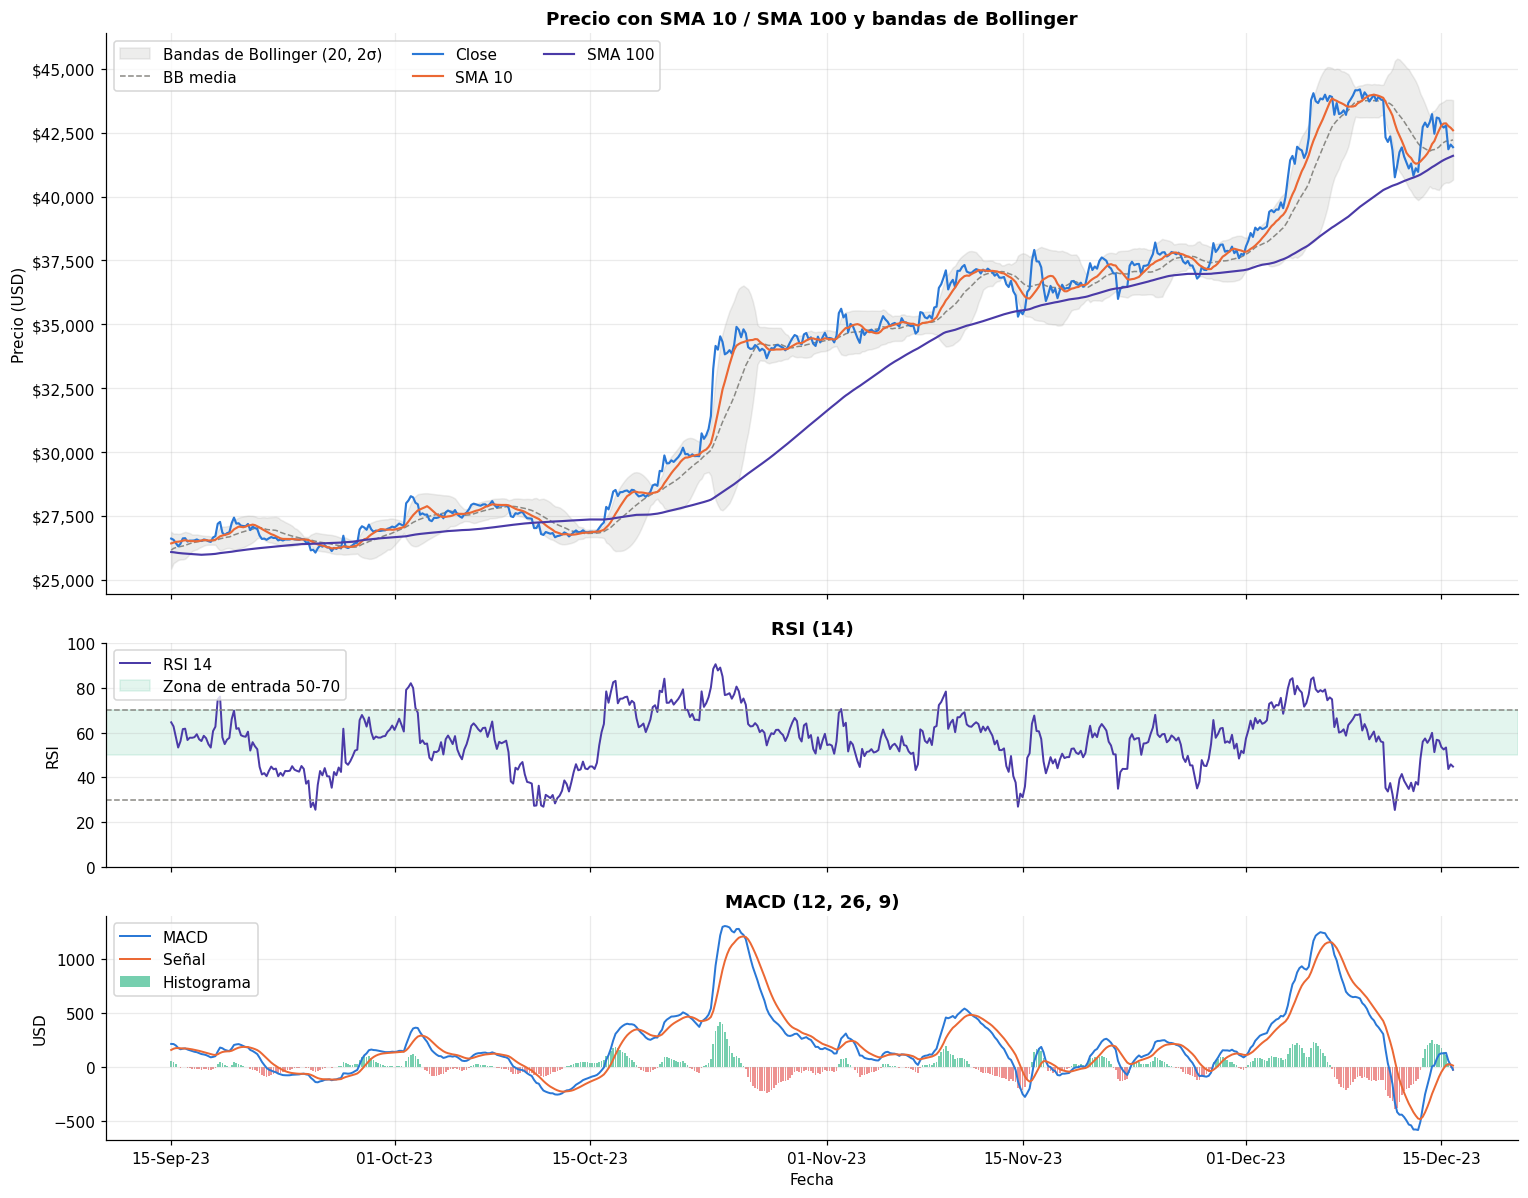

In [15]:
w = ind.loc["2023-09-15":"2023-12-15"]
fig, axs = plt.subplots(3, 1, figsize=(14, 11), sharex=True, gridspec_kw={"height_ratios": [3, 1.2, 1.2]})
ax = axs[0]
ax.fill_between(w.index, w["bb_low"], w["bb_high"], color=GRAY, alpha=0.15, label="Bandas de Bollinger (20, 2σ)")
ax.plot(w.index, w["bb_mid"], color=GRAY, lw=1, ls="--", label="BB media")
ax.plot(w.index, w["close"], color=BLUE, lw=1.4, label="Close")
ax.plot(w.index, w["sma_10"], color=ORANGE, lw=1.4, label="SMA 10")
ax.plot(w.index, w["sma_100"], color=VIOLET, lw=1.4, label="SMA 100")
ax.set_title("Precio con SMA 10 / SMA 100 y bandas de Bollinger")
ax.set_ylabel("Precio (USD)"); ax.legend(loc="upper left", ncol=3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

axs[1].plot(w.index, w["rsi_14"], color=VIOLET, lw=1.3, label="RSI 14")
axs[1].axhspan(50, 70, color=AQUA, alpha=0.12, label="Zona de entrada 50-70")
axs[1].axhline(70, color=GRAY, ls="--", lw=1); axs[1].axhline(30, color=GRAY, ls="--", lw=1)
axs[1].set_ylim(0, 100); axs[1].set_ylabel("RSI"); axs[1].set_title("RSI (14)"); axs[1].legend(loc="upper left")

axs[2].bar(w.index, w["macd_diff"], width=0.12, color=np.where(w["macd_diff"] >= 0, AQUA, BAD), alpha=0.6, label="Histograma")
axs[2].plot(w.index, w["macd"], color=BLUE, lw=1.3, label="MACD")
axs[2].plot(w.index, w["macd_signal"], color=ORANGE, lw=1.3, label="Señal")
axs[2].set_title("MACD (12, 26, 9)"); axs[2].set_ylabel("USD"); axs[2].set_xlabel("Fecha"); axs[2].legend(loc="upper left")
axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b-%y"))
plt.tight_layout(); plt.show()

## 7. Regla de entrada: 2 condiciones
```
C1 = SMA_10 > SMA_100  AND  close > BB_mid
C2 = MACD > señal  AND  50 < RSI < 70  AND  close < BB_high
entry_signal = C1 AND C2
entry_trigger = entry_signal AND (MACD > señal) AND (MACD(t-1) <= señal(t-1))
```
La señal se evalúa al cierre de la barra *t* y la orden se ejecuta al open de *t+1*. El disparador exige un cruce alcista del MACD sobre su señal para evitar entrar solo porque el setup sigue activo desde hace varias barras.


In [16]:
sig = entry_conditions(ind, P)
data = ind.join(sig)
conteo = pd.DataFrame({
    "Barras donde se cumple": [sig["c1_tendencia"].sum(), sig["c2_momentum"].sum(), sig["entry_signal"].sum(), sig["entry_trigger"].sum()],
}, index=["C1 tendencia (SMA + BB_mid)", "C2 momentum (MACD + RSI + BB_high)", "C1 y C2 (señal)", "Nuevos setups (trigger)"])
conteo["% de las barras"] = 100 * conteo["Barras donde se cumple"] / len(sig)
display(conteo)
print("Ejemplo de barras con trigger de entrada:")
display(data.loc[data["entry_trigger"], ["close", "sma_10", "sma_100", "bb_mid", "bb_high", "rsi_14", "macd", "macd_signal", "atr_14"]].head(10))

,Barras donde se cumple,% de las barras
C1 tendencia (SMA + BB_mid),1150,33.33
C2 momentum (MACD + RSI + BB_high),744,21.57
C1 y C2 (señal),448,12.99
Nuevos setups (trigger),25,0.72


Ejemplo de barras con trigger de entrada:


,close,sma_10,sma_100,bb_mid,bb_high,rsi_14,macd,macd_signal,atr_14
datetime,,,,,,,,,
2022-08-03 12:00:00,"23,391.53","23,031.88","22,832.25","23,234.19","23,849.00",53.96,-54.97,-58.48,348.71
2022-08-05 04:00:00,"23,192.03","22,969.58","22,925.27","23,000.73","23,460.29",52.16,-82.93,-91.09,344.78
2022-08-07 16:00:00,"23,169.22","23,101.55","22,905.54","23,062.06","23,463.59",52.19,-11.35,-15.99,229.63
2022-08-10 16:00:00,"23,619.36","23,310.74","23,057.10","23,471.99","24,272.84",54.43,40.72,39.23,313.07
2022-08-12 20:00:00,"24,403.04","24,149.18","23,419.33","23,851.19","24,893.88",60.42,192.54,189.43,306.78
2022-10-29 16:00:00,"20,841.29","20,591.15","19,588.52","20,605.52","21,054.85",65.40,228.55,227.14,210.11
2022-11-04 04:00:00,"20,602.38","20,281.30","19,977.74","20,379.85","20,653.35",58.41,-42.35,-56.04,181.47
2022-12-13 04:00:00,"17,163.82","17,066.94","16,913.30","17,118.14","17,289.69",56.03,6.05,4.75,83.51
2023-01-06 20:00:00,"16,944.72","16,848.59","16,744.20","16,829.21","16,966.20",65.88,45.70,42.75,73.71


## 8. Backtest orientado a eventos (periodo completo)
Motor barra por barra con estado explícito de cash, posición y equity (`src/backtest.py`).

In [17]:
res = backtest(data, P)
eq, trades = res["equity"], res["trades"]
display(eq.head())
print("Estado final:"); display(eq.tail(3))

,cash,units,equity,en_posicion
datetime,,,,
2022-06-01 00:00:00,"100,000.00",0.00,"100,000.00",False
2022-06-01 04:00:00,"100,000.00",0.00,"100,000.00",False
2022-06-01 08:00:00,"100,000.00",0.00,"100,000.00",False
2022-06-01 12:00:00,"100,000.00",0.00,"100,000.00",False
2022-06-01 16:00:00,"100,000.00",0.00,"100,000.00",False


Estado final:


,cash,units,equity,en_posicion
datetime,,,,
2023-12-30 16:00:00,"103,118.33",0.00,"103,118.33",False
2023-12-30 20:00:00,"103,118.33",0.00,"103,118.33",False
2023-12-31 00:00:00,"103,118.33",0.00,"103,118.33",False


### 8.1 Tabla de operaciones: cuándo entra y cuándo sale la estrategia

In [18]:
cols = ["entrada", "salida", "precio_entrada", "precio_salida", "stop_inicial", "take_profit",
        "unidades", "nocional", "costos", "pnl", "retorno_%", "R", "motivo", "barras"]
tabla_ops = trades[cols].copy()
tabla_ops.index = range(1, len(tabla_ops) + 1); tabla_ops.index.name = "Operación"
tabla_ops.to_csv("operaciones.csv")
print(f"{len(tabla_ops)} operaciones cerradas (lista completa en operaciones.csv). Primeras 25:")
display(tabla_ops.head(25))
print("Últimas 10:"); display(tabla_ops.tail(10))
print("Posición que sigue abierta al final de la muestra (no tocó SL ni TP):")
display(pd.Series(res["open_position"]).to_frame("valor") if res["open_position"] else "Ninguna")

17 operaciones cerradas (lista completa en operaciones.csv). Primeras 25:


,entrada,salida,precio_entrada,precio_salida,stop_inicial,take_profit,unidades,nocional,costos,pnl,retorno_%,R,motivo,barras
Operación,,,,,,,,,,,,,,
1,2022-08-03 16:00:00,2022-08-09 08:00:00,"23,378.78","23,367.09","21,983.96","24,424.90",1.43,"33,522.27",67.03,-83.79,-0.25,-0.04,break_even,35
2,2022-08-10 20:00:00,2022-08-11 04:00:00,"23,650.07","24,576.99","22,397.78","24,589.28",1.60,"37,739.42",76.96,"1,402.17",3.72,0.70,take_profit,3
3,2022-08-13 00:00:00,2022-08-13 08:00:00,"24,414.39","24,402.18","23,187.28","25,334.72",1.65,"40,316.24",80.61,-100.77,-0.25,-0.05,break_even,3
4,2022-10-29 20:00:00,2022-11-04 16:00:00,"20,851.72","20,841.29","20,011.29","21,482.04",2.41,"50,225.81",100.43,-125.54,-0.25,-0.06,break_even,36
5,2022-12-13 08:00:00,2022-12-13 08:00:00,"17,173.04","17,414.84","16,839.01","17,423.55",5.88,"100,991.08",203.40,"1,218.62",1.21,0.62,take_profit,1
6,2023-01-07 00:00:00,2023-01-09 00:00:00,"16,960.59","17,173.13","16,665.76","17,181.72",6.03,"102,208.47",205.70,"1,075.10",1.05,0.61,take_profit,13
7,2023-02-01 20:00:00,2023-02-02 00:00:00,"23,400.80","24,097.11","22,456.30","24,109.17",2.19,"51,229.74",103.98,"1,420.41",2.77,0.69,take_profit,2
8,2023-02-18 00:00:00,2023-02-19 20:00:00,"24,577.58","24,526.82","22,969.47","25,783.66",1.30,"32,036.16",64.01,-130.17,-0.41,-0.06,break_even,12
9,2023-03-29 08:00:00,2023-03-30 16:00:00,"28,099.68","28,085.63","26,182.40","29,537.65",1.09,"30,682.57",61.35,-76.69,-0.25,-0.04,break_even,9


Últimas 10:


,entrada,salida,precio_entrada,precio_salida,stop_inicial,take_profit,unidades,nocional,costos,pnl,retorno_%,R,motivo,barras
Operación,,,,,,,,,,,,,,
8,2023-02-18 00:00:00,2023-02-19 20:00:00,"24,577.58","24,526.82","22,969.47","25,783.66",1.30,"32,036.16",64.01,-130.17,-0.41,-0.06,break_even,12
9,2023-03-29 08:00:00,2023-03-30 16:00:00,"28,099.68","28,085.63","26,182.40","29,537.65",1.09,"30,682.57",61.35,-76.69,-0.25,-0.04,break_even,9
10,2023-03-31 20:00:00,2023-04-11 00:00:00,"28,484.32","29,823.16","26,679.32","29,838.08",1.16,"33,013.15",67.58,"1,484.12",4.50,0.71,take_profit,62
11,2023-04-18 16:00:00,2023-04-19 20:00:00,"30,213.21","29,014.30","29,028.82","31,101.51",1.79,"54,122.45",106.10,"-2,253.77",-4.16,-1.06,stop_loss,8
12,2023-06-30 04:00:00,2023-06-30 08:00:00,"30,745.30","30,729.93","29,401.52","31,753.14",1.55,"47,511.72",95.00,-118.76,-0.25,-0.06,break_even,2
13,2023-07-03 04:00:00,2023-07-04 16:00:00,"30,774.49","30,759.11","29,718.62","31,566.40",1.96,"60,455.07",120.88,-151.11,-0.25,-0.07,break_even,10
14,2023-11-05 04:00:00,2023-11-08 00:00:00,"35,314.59","35,296.94","33,828.52","36,429.15",1.39,"49,219.16",98.41,-123.02,-0.25,-0.06,break_even,18
15,2023-11-15 20:00:00,2023-11-26 12:00:00,"37,536.89","37,518.12","35,483.62","39,076.84",1.01,"37,819.72",75.62,-94.53,-0.25,-0.05,break_even,65
16,2023-12-01 08:00:00,2023-12-01 12:00:00,"38,275.04","38,255.90","36,865.21","39,332.41",1.47,"56,112.35",112.20,-140.25,-0.25,-0.07,break_even,2


Posición que sigue abierta al final de la muestra (no tocó SL ni TP):


'Ninguna'

### 8.2 Gráfica 3: entradas y salidas sobre el precio

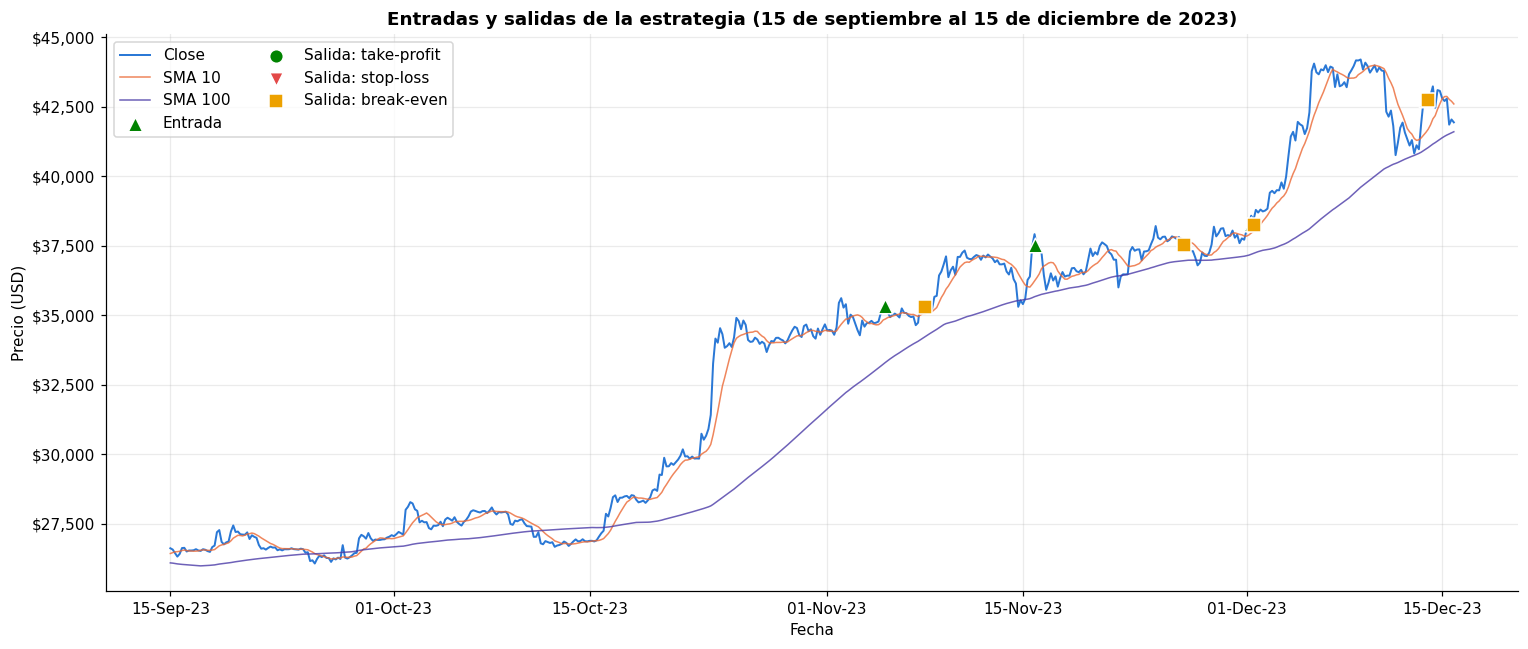

In [19]:
w = data.loc["2023-09-15":"2023-12-15"]
tw = trades[(trades["entrada"] >= w.index[0]) & (trades["entrada"] <= w.index[-1])]
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(w.index, w["close"], color=BLUE, lw=1.3, label="Close")
ax.plot(w.index, w["sma_10"], color=ORANGE, lw=1, alpha=0.8, label="SMA 10")
ax.plot(w.index, w["sma_100"], color=VIOLET, lw=1, alpha=0.8, label="SMA 100")
ax.scatter(tw["entrada"], tw["precio_entrada"], marker="^", s=90, color=GOOD, edgecolor="white", zorder=5, label="Entrada")
estilos = {"take_profit": ("o", GOOD, "Salida: take-profit"), "stop_loss": ("v", BAD, "Salida: stop-loss"), "break_even": ("s", WARN, "Salida: break-even")}
for motivo, (mk, colr, lab) in estilos.items():
    s = tw[tw["motivo"] == motivo]
    ax.scatter(s["salida"], s["precio_salida"], marker=mk, s=80, color=colr, edgecolor="white", zorder=5, label=lab)
ax.set_title("Entradas y salidas de la estrategia (15 de septiembre al 15 de diciembre de 2023)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Precio (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b-%y"))
ax.legend(loc="upper left", ncol=2); plt.tight_layout(); plt.show()

## 9. ¿Qué tanto sirvió la estrategia? Entradas, salidas y resultado por tipo de salida

,Periodo completo
Entradas ejecutadas,17
Salidas (operaciones cerradas),17
Posiciones abiertas al final,0
Ganadoras,5
Perdedoras,12


,Operaciones,PnL_total,PnL_promedio,R_promedio,Holding_promedio_barras_4h,Costos,% de operaciones
motivo,,,,,,,
break_even,11,"-1,228.32",-111.67,-0.05,17.64,942.49,64.71
stop_loss,1,"-2,253.77","-2,253.77",-1.06,8.00,106.10,5.88
take_profit,5,"6,600.42","1,320.08",0.66,16.20,657.62,29.41


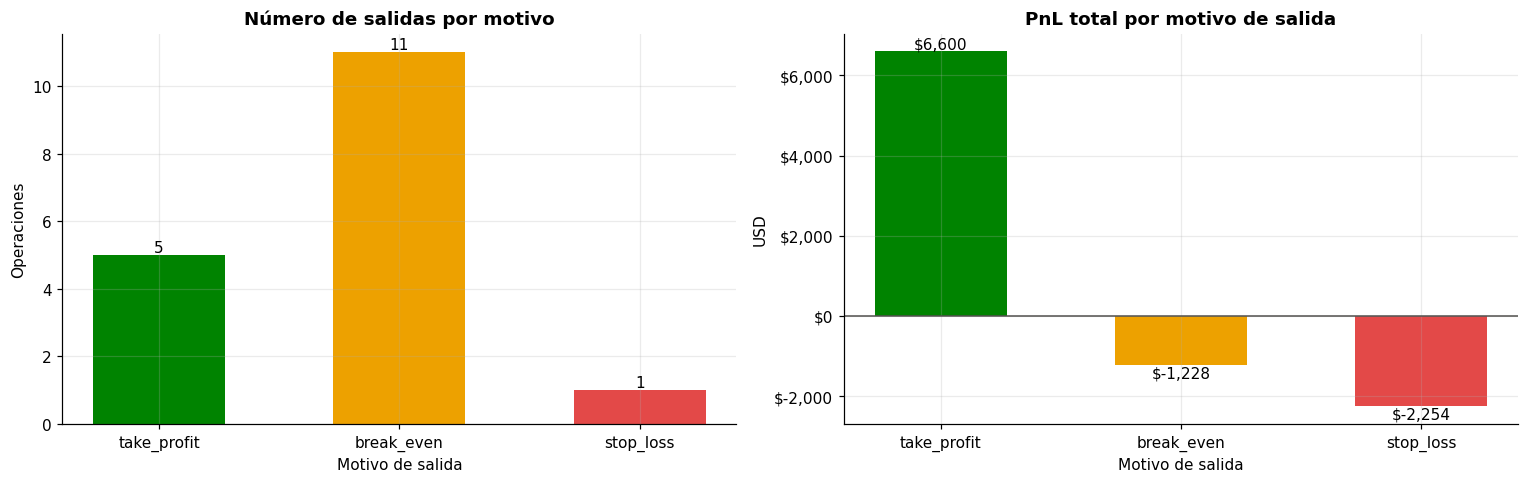

In [20]:
resumen_ops = pd.DataFrame({
    "Entradas ejecutadas": [len(trades) + (1 if res["open_position"] else 0)],
    "Salidas (operaciones cerradas)": [len(trades)],
    "Posiciones abiertas al final": [1 if res["open_position"] else 0],
    "Ganadoras": [(trades["pnl"] > 0).sum()],
    "Perdedoras": [(trades["pnl"] <= 0).sum()],
}, index=["Periodo completo"]).T
display(resumen_ops)

por_motivo = trades.groupby("motivo").agg(Operaciones=("pnl", "size"), PnL_total=("pnl", "sum"),
                                           PnL_promedio=("pnl", "mean"), R_promedio=("R", "mean"),
                                           Holding_promedio_barras_4h=("barras", "mean"), Costos=("costos", "sum"))
por_motivo["% de operaciones"] = 100 * por_motivo["Operaciones"] / len(trades)
display(por_motivo)

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
orden = ["take_profit", "break_even", "stop_loss"]; colores = [GOOD, WARN, BAD]
pm = por_motivo.reindex(orden)
axs[0].bar(orden, pm["Operaciones"], color=colores, width=0.55)
for i, v in enumerate(pm["Operaciones"]): axs[0].text(i, v, f"{v:.0f}", ha="center", va="bottom")
axs[0].set_title("Número de salidas por motivo"); axs[0].set_xlabel("Motivo de salida"); axs[0].set_ylabel("Operaciones")
axs[1].bar(orden, pm["PnL_total"], color=colores, width=0.55)
for i, v in enumerate(pm["PnL_total"]): axs[1].text(i, v, f"${v:,.0f}", ha="center", va="bottom" if v >= 0 else "top")
axs[1].axhline(0, color="#52514e", lw=1)
axs[1].set_title("PnL total por motivo de salida"); axs[1].set_xlabel("Motivo de salida"); axs[1].set_ylabel("USD")
axs[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout(); plt.show()

## 10. Curva de equity y curva de drawdown

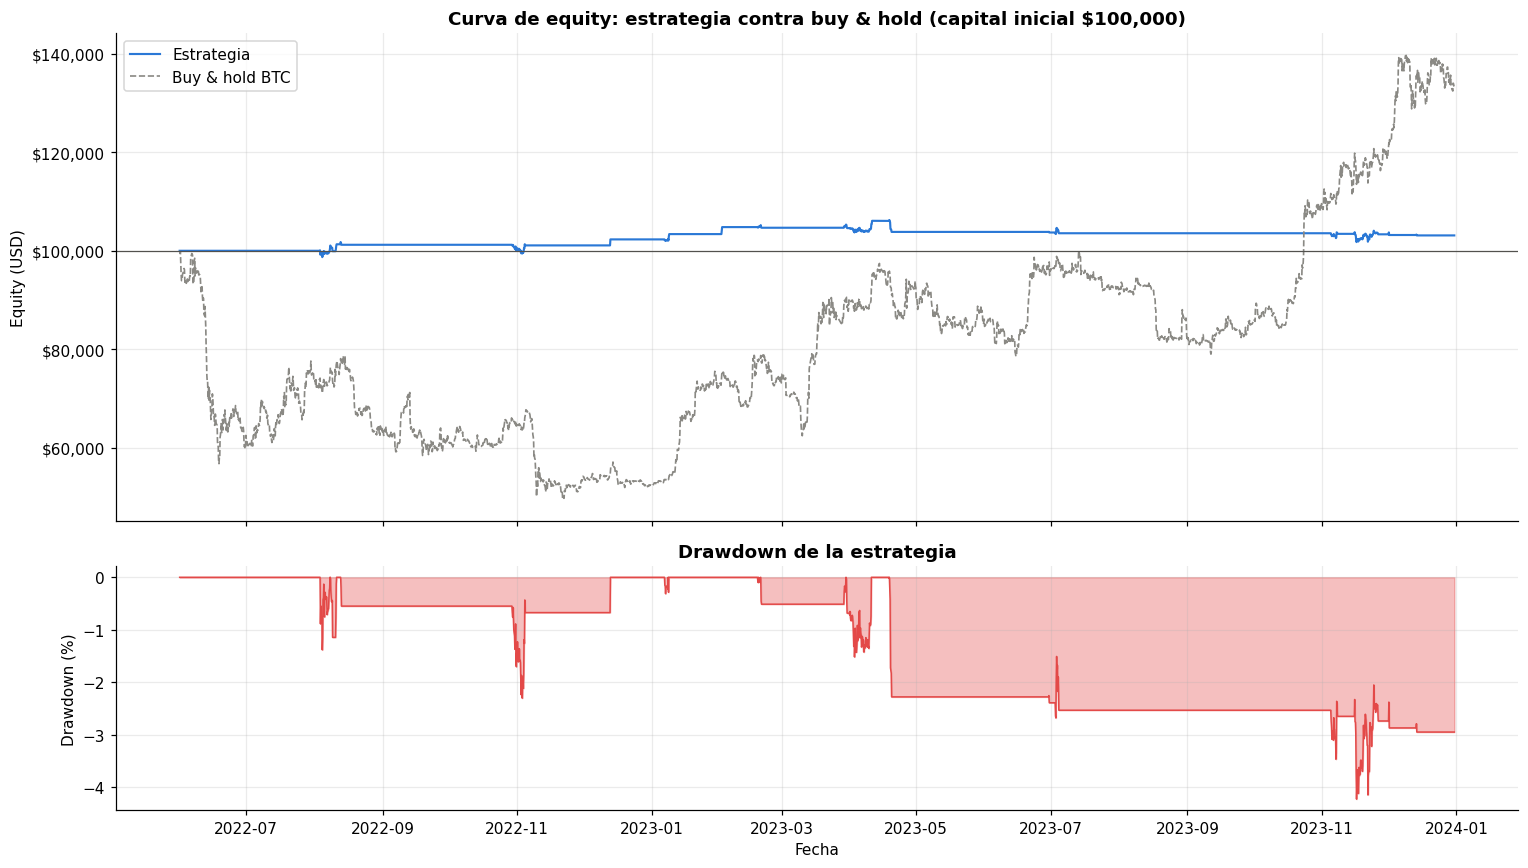

In [21]:
bh = P.initial_cash * data["close"] / data["close"].iloc[0]
dd = M.drawdown(eq["equity"])
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axs[0].plot(eq.index, eq["equity"], color=BLUE, lw=1.4, label="Estrategia")
axs[0].plot(bh.index, bh, color=GRAY, lw=1.1, ls="--", label="Buy & hold BTC")
axs[0].axhline(P.initial_cash, color="#52514e", lw=0.8)
axs[0].set_title("Curva de equity: estrategia contra buy & hold (capital inicial $100,000)")
axs[0].set_ylabel("Equity (USD)"); axs[0].legend(loc="upper left")
axs[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axs[1].fill_between(dd.index, 100 * dd, 0, color=BAD, alpha=0.35)
axs[1].plot(dd.index, 100 * dd, color=BAD, lw=1)
axs[1].set_title("Drawdown de la estrategia"); axs[1].set_ylabel("Drawdown (%)"); axs[1].set_xlabel("Fecha")
plt.tight_layout(); plt.show()

## 11. Métricas de desempeño y capital final

In [22]:
resumen = M.summary(res)
display(resumen.to_frame("Periodo completo"))
print(f"Capital final: ${resumen['Capital final ($)']:,.2f}  (inicio $100,000)")
print(f"Calmar = {resumen['Calmar']:.2f}  ->  {resumen['Veredicto (Calmar)']}")

,Periodo completo
Capital inicial ($),"100,000.00"
Capital final ($),"103,118.33"
Ganancia/Pérdida ($),"3,118.33"
Rendimiento total (%),3.12
Rendimiento anualizado CAGR (%),1.96
Volatilidad anualizada (%),4.08
Sharpe (anualizado),0.50
Drawdown máximo (%),-4.22
Calmar,0.46
Operaciones cerradas,17


Capital final: $103,118.33  (inicio $100,000)
Calmar = 0.46  ->  NO VIABLE


### 11.1 Resultados por tramo (train / test / validation)
Cada tramo se corre por separado con $100,000; los indicadores se calculan dentro de cada tramo.

In [23]:
por_tramo = {"Completo": resumen}
for k, v in splits.items():
    por_tramo[k] = M.summary(run_pipeline(v, P))
tabla_tramos = pd.DataFrame(por_tramo)
display(tabla_tramos)

,Completo,Train,Test,Validation
Capital inicial ($),"100,000.00","100,000.00","100,000.00","100,000.00"
Capital final ($),"103,118.33","103,829.69","99,740.09","99,573.67"
Ganancia/Pérdida ($),"3,118.33","3,829.69",-259.91,-426.33
Rendimiento total (%),3.12,3.83,-0.26,-0.43
Rendimiento anualizado CAGR (%),1.96,4.02,-0.82,-1.35
Volatilidad anualizada (%),4.08,4.30,2.19,4.81
Sharpe (anualizado),0.50,0.95,-0.37,-0.26
Drawdown máximo (%),-4.22,-2.30,-1.04,-1.94
Calmar,0.46,1.75,-0.79,-0.69
Operaciones cerradas,17,11,2,4


## 12. Sensibilidad a costos (0 a 50 bps de ida y vuelta)

,Capital final ($),Sharpe,Calmar,Drawdown máx (%)
Costo ida y vuelta (bps),,,,
0,"105,294.06",0.81,0.88,-3.76
5,"104,859.13",0.75,0.79,-3.85
10,"104,425.93",0.69,0.70,-3.95
15,"103,994.44",0.63,0.62,-4.04
20,"103,564.67",0.56,0.54,-4.13
25,"103,136.60",0.50,0.47,-4.23
30,"102,710.23",0.44,0.39,-4.32
35,"102,285.55",0.37,0.33,-4.41
40,"101,862.55",0.31,0.26,-4.51


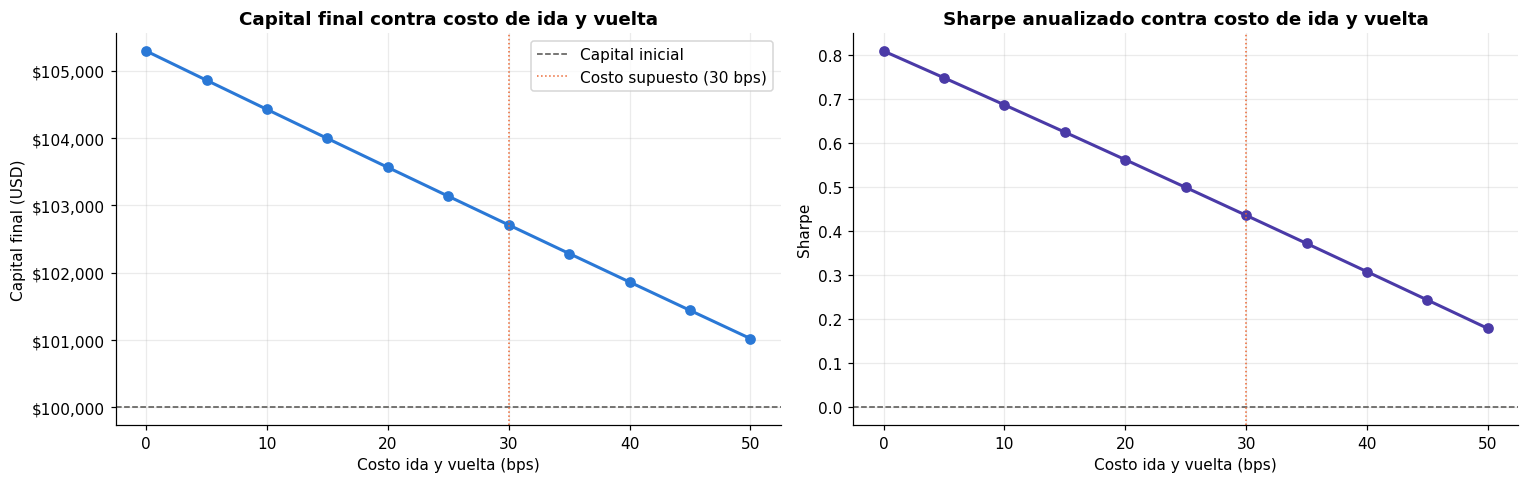

In [24]:
sens = []
for bps in range(0, 55, 5):
    r = backtest(data, with_costs(P, bps)); e = r["equity"]["equity"]
    sens.append({"Costo ida y vuelta (bps)": bps, "Capital final ($)": e.iloc[-1], "Sharpe": M.sharpe(e),
                 "Calmar": M.calmar(e), "Drawdown máx (%)": 100 * M.max_drawdown(e)})
sens = pd.DataFrame(sens).set_index("Costo ida y vuelta (bps)")
display(sens)

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
axs[0].plot(sens.index, sens["Capital final ($)"], color=BLUE, lw=2, marker="o", ms=6)
axs[0].axhline(P.initial_cash, color="#52514e", lw=1, ls="--", label="Capital inicial")
axs[0].axvline(30, color=ORANGE, lw=1, ls=":", label="Costo supuesto (30 bps)")
axs[0].set_title("Capital final contra costo de ida y vuelta"); axs[0].set_xlabel("Costo ida y vuelta (bps)"); axs[0].set_ylabel("Capital final (USD)")
axs[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}")); axs[0].legend()
axs[1].plot(sens.index, sens["Sharpe"], color=VIOLET, lw=2, marker="o", ms=6)
axs[1].axhline(0, color="#52514e", lw=1, ls="--"); axs[1].axvline(30, color=ORANGE, lw=1, ls=":")
axs[1].set_title("Sharpe anualizado contra costo de ida y vuelta"); axs[1].set_xlabel("Costo ida y vuelta (bps)"); axs[1].set_ylabel("Sharpe")
plt.tight_layout(); plt.show()

## 13. Win rate teórico (p*) contra empírico
Sin costos: p* = 1 / (1 + R) con R = 3 / 1.5 = 2. Con costos, cada operación paga c (en unidades de riesgo R) al ganar y al perder: p*_costos = (1 + c) / (R + 1).

Riesgo típico por operación: 4.28% del precio -> 30 bps equivalen a 0.07 R


,Valor (%)
p* teórico sin costos,57.14
p* teórico con costos de 30 bps,61.15
Win rate empírico (PnL neto > 0),29.41
% de operaciones que tocan el TP,29.41


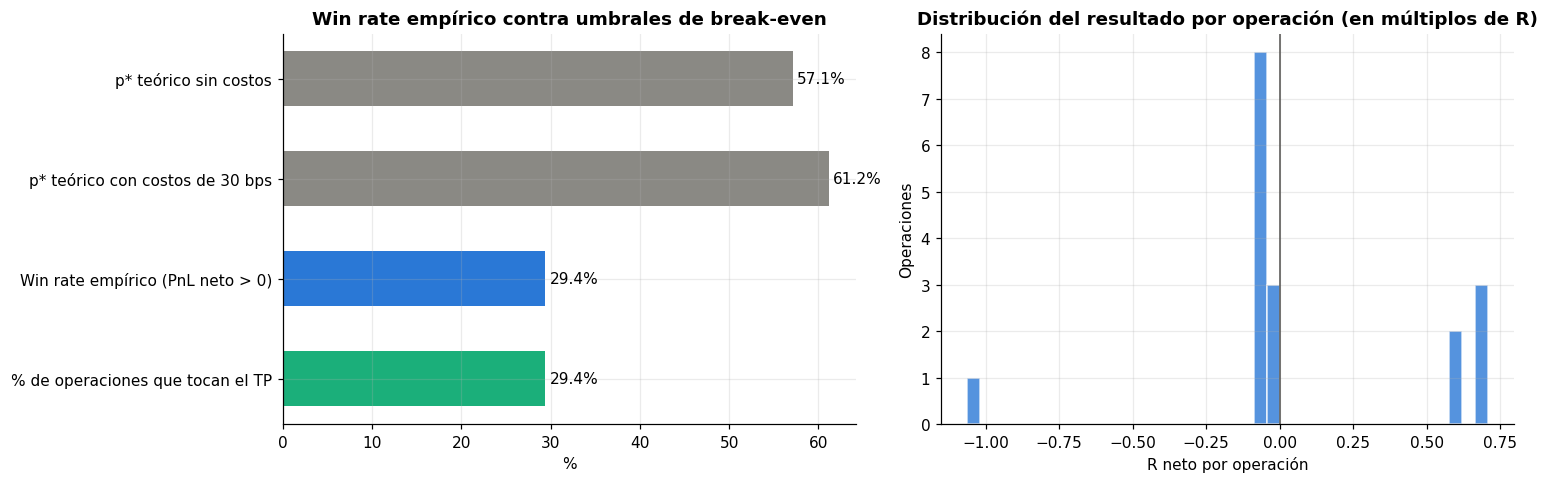

In [25]:
riesgo_pct = (P.sl_atr * data["atr_14"] / data["close"]).median()
c_R = 0.0030 / riesgo_pct
wr = pd.DataFrame({
    "Valor (%)": [100 * P.breakeven_winrate, 100 * (1 + c_R) / (P.reward_risk + 1), 100 * M.win_rate(trades),
                  100 * (trades["motivo"] == "take_profit").mean()]},
    index=["p* teórico sin costos", "p* teórico con costos de 30 bps", "Win rate empírico (PnL neto > 0)", "% de operaciones que tocan el TP"])
print(f"Riesgo típico por operación: {100*riesgo_pct:.2f}% del precio -> 30 bps equivalen a {c_R:.2f} R")
display(wr)

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
axs[0].barh(wr.index[::-1], wr["Valor (%)"][::-1], color=[AQUA, BLUE, GRAY, GRAY], height=0.55)
for i, v in enumerate(wr["Valor (%)"][::-1]): axs[0].text(v + 0.5, i, f"{v:.1f}%", va="center")
axs[0].set_title("Win rate empírico contra umbrales de break-even"); axs[0].set_xlabel("%")
axs[1].hist(trades["R"], bins=40, color=BLUE, alpha=0.8, edgecolor="white")
axs[1].axvline(0, color="#52514e", lw=1)
axs[1].set_title("Distribución del resultado por operación (en múltiplos de R)"); axs[1].set_xlabel("R neto por operación"); axs[1].set_ylabel("Operaciones")
plt.tight_layout(); plt.show()

## 14. Pruebas: unit tests, golden file y truncamiento del pipeline
- (a) stop y target en la misma barra → `stop_loss`
- (b) el sizing regresa exactamente ρ × equity
- (c) nunca dos posiciones abiertas
- Golden file: equity final calculado a mano (103,969.33 y 99,973.33)
- Truncamiento: indicadores → señales → combinación → backtest recalculado sobre `df.iloc[:t+1]`

In [26]:
out = subprocess.run([sys.executable, "-m", "pytest", "-v", "--color=no", "-p", "no:cacheprovider", "tests"], capture_output=True, text=True)
print(out.stdout[-2500:])

============================= test session starts =============================
platform win32 -- Python 3.12.4, pytest-7.4.4, pluggy-1.0.0 -- c:\Users\Isabela\anaconda3\python.exe
rootdir: c:\Users\Isabela\Documents\Iteso\9no Semestre\Trading\Act05
plugins: anyio-4.10.0, langsmith-0.4.29
collecting ... collected 12 items

tests/test_strategy.py::test_same_bar_stop_and_target_closes_as_stop PASSED [  8%]
tests/test_strategy.py::test_sizing_returns_exact_risk_budget[100000-30000-29500-0.02] PASSED [ 16%]
tests/test_strategy.py::test_sizing_returns_exact_risk_budget[100000-100-85-0.02] PASSED [ 25%]
tests/test_strategy.py::test_sizing_returns_exact_risk_budget[57321.4-42310.0-42014.87-0.01] PASSED [ 33%]
tests/test_strategy.py::test_never_two_open_positions PASSED             [ 41%]
tests/test_strategy.py::test_golden_take_profit PASSED                   [ 50%]
tests/test_strategy.py::test_golden_break_even PASSED                    [ 58%]
tests/test_strategy.py::test_pipeline_truncation

### Prueba de truncamiento mostrada en tabla

In [27]:
filas = []
for t in [800, 1800, 3000]:
    full = run_pipeline(df, P); part = run_pipeline(df.iloc[:t + 1], P)
    for col in ["sma_10", "rsi_14", "macd", "bb_mid", "atr_14"]:
        filas.append({"t": t, "fecha": df.index[t], "variable": col, "completo": full["data"][col].iloc[t],
                      "truncado": part["data"][col].iloc[-1]})
    filas.append({"t": t, "fecha": df.index[t], "variable": "equity", "completo": full["equity"]["equity"].iloc[t],
                  "truncado": part["equity"]["equity"].iloc[-1]})
trunc = pd.DataFrame(filas); trunc["diferencia"] = trunc["completo"] - trunc["truncado"]
trunc

,t,fecha,variable,completo,truncado,diferencia
0,800,2022-10-12 08:00:00,sma_10,"19,096.33","19,096.33",0.00
1,800,2022-10-12 08:00:00,rsi_14,37.97,37.97,0.00
2,800,2022-10-12 08:00:00,macd,-143.64,-143.64,0.00
3,800,2022-10-12 08:00:00,bb_mid,"19,251.64","19,251.64",0.00
4,800,2022-10-12 08:00:00,atr_14,134.16,134.16,0.00
5,800,2022-10-12 08:00:00,equity,"101,217.61","101,217.61",0.00
6,1800,2023-03-30 20:00:00,sma_10,"28,386.85","28,386.85",0.00
7,1800,2023-03-30 20:00:00,rsi_14,52.22,52.22,0.00
8,1800,2023-03-30 20:00:00,macd,195.58,195.58,0.00
9,1800,2023-03-30 20:00:00,bb_mid,"27,836.40","27,836.40",0.00


## 15. Auditoría de sesgos
| Sesgo | Estado | Evidencia |
|---|---|---|
| Look-ahead | Controlado | Indicadores causales; la prueba de truncamiento del pipeline completo da diferencia 0 en t = 800, 1800 y 3000; la orden se ejecuta al open de t+1 con el ATR de t. |
| Survivorship | Bajo | Un solo activo (BTC) que existió todo el periodo; no se filtró un universo. Elegir BTC por ser el cripto más líquido es un sesgo de selección leve. |
| Overfitting / data snooping | Moderado | Parámetros estándar (10/40, RSI 14, MACD 12-26-9, BB 20-2) fijados antes de correr y sin optimizar; se reporta train, test y validation. No se ajustó nada después de ver los resultados. |
| Ejecución optimista | Controlado parcialmente | Slippage de 5 bps, entrada al open siguiente, empate → stop, gap → salida al open. Limitación: ≈3,700 barras de 5 min faltantes; en esos huecos el precio real pudo saltar el stop. |
| Selección / periodo de muestra | Relevante | Solo 19 meses (bajista 2022 con FTX, recuperación 2023). El resultado puede no generalizar a otros regímenes. |

## 16. Conclusión: ¿es viable la estrategia?

In [28]:
r0 = backtest(data, with_costs(P, 0)); s0 = M.summary(r0)
concl = pd.DataFrame({"Con costos (30 bps)": resumen, "Sin costos (0 bps)": s0}).loc[
    ["Capital final ($)", "Rendimiento total (%)", "Rendimiento anualizado CAGR (%)", "Drawdown máximo (%)",
     "Calmar", "Sharpe (anualizado)", "Win rate empírico (%)", "Costos totales ($)", "Veredicto (Calmar)"]]
display(concl)
bh_ret = 100 * (data["close"].iloc[-1] / data["close"].iloc[0] - 1)
print(f"Buy & hold BTC en el mismo periodo: {bh_ret:+.1f}%")
print(f"Con $100,000 iniciales la estrategia termina con ${resumen['Capital final ($)']:,.2f} "
      f"({resumen['Rendimiento total (%)']:+.1f}%). Calmar = {resumen['Calmar']:.2f} -> {resumen['Veredicto (Calmar)']}.")

,Con costos (30 bps),Sin costos (0 bps)
Capital final ($),"103,118.33","105,294.06"
Rendimiento total (%),3.12,5.29
Rendimiento anualizado CAGR (%),1.96,3.31
Drawdown máximo (%),-4.22,-3.76
Calmar,0.46,0.88
Sharpe (anualizado),0.50,0.81
Win rate empírico (%),29.41,29.41
Costos totales ($),"1,706.21",0.00
Veredicto (Calmar),NO VIABLE,MARGINAL


Buy & hold BTC en el mismo periodo: +33.4%
Con $100,000 iniciales la estrategia termina con $103,118.33 (+3.1%). Calmar = 0.46 -> NO VIABLE.


**Lectura de los resultados (barras de 4 horas)**

1. **Capital final.** Con costos realistas (30 bps ida y vuelta) los $100,000 terminan en ≈ **$69,200** (−30.8 %). En el mismo periodo, comprar BTC y mantenerlo dio +33 %.
2. **Calmar.** El Calmar es **negativo (≈ −0.60)**: el CAGR es de −20.7 % y el drawdown máximo de −34.8 %. Con el criterio del SPEC (Calmar > 1 viable, 0.5 a 1 marginal, < 0.5 no viable) la estrategia **NO es viable**.
3. **Por tramo.** Train (Calmar −0.74) y test (−2.06) son negativos. Validation sale marginal (Calmar 0.61, +1.2 %), pero con solo 22 operaciones en 4 meses; un tramo positivo no compensa los otros dos.
4. **Qué mejoró con 4 horas.** El ATR pasó de ≈ 0.47 % a ≈ 1.07 % del precio, así que el costo bajó de 0.43 R a 0.19 R por operación. Hubo 96 operaciones en lugar de 423, el turnover cayó de ≈ 514 a ≈ 111 veces el equity al año y los costos de ≈ $49,000 a ≈ $13,400. La pérdida se redujo de −68.5 % a −30.8 %.
5. **Por qué sigue sin funcionar.** El win rate empírico (≈ 23 %) está por debajo del p* sin costos (33.3 %) y del p* con costos (≈ 40 %). **Aun sin costos** la versión de 4 h pierde (−10.6 %, Calmar −0.30). Con barras de 4 horas el problema ya no son los costos, sino que la señal no tiene ventaja: el precio toca el stop (49 veces) mucho más que el target (22 veces), y el break-even corta 25 operaciones que podrían haber seguido subiendo.



## 17. Comparación: barras de 1 hora contra barras de 4 horas
Misma estrategia y mismos parámetros; solo cambia la frecuencia.

,Barras 1h,Barras 4h
ATR mediano (% del precio),0.47,1.07
Costo por operación (en R),0.16,0.07
Operaciones cerradas,93,17
Win rate empírico (%),36.56,29.41
Costos totales ($),"15,565.48","1,706.21"
Turnover anual (x equity),105.16,10.50
Capital final sin costos ($),"119,116.84","105,294.06"
Capital final ($),"84,935.68","103,118.33"
Drawdown máximo (%),-23.86,-4.22
Calmar,-0.41,0.46


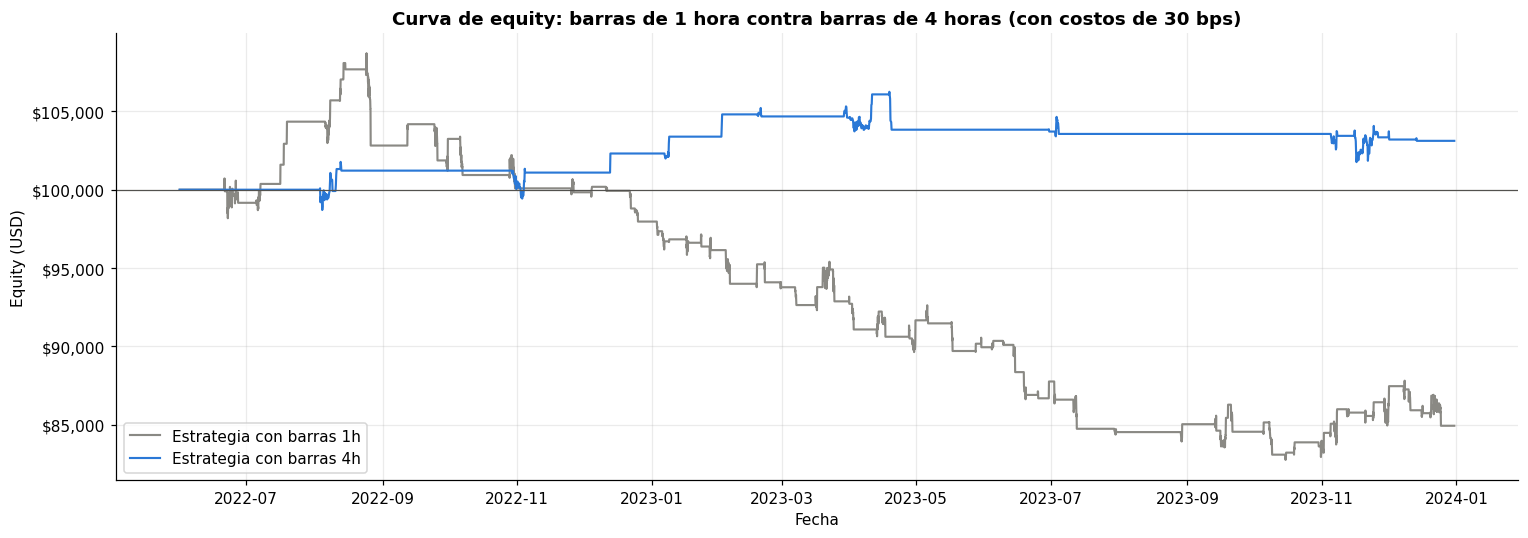

In [29]:
comp = {}
for f in ["1h", "4h"]:
    d_f = load_bars(DATA, f)
    r_f = run_pipeline(d_f, P); s_f = M.summary(r_f)
    s_f["ATR mediano (% del precio)"] = 100 * (r_f["data"]["atr_14"] / r_f["data"]["close"]).median()
    s_f["Costo por operación (en R)"] = 0.0030 / (P.sl_atr * r_f["data"]["atr_14"] / r_f["data"]["close"]).median()
    s_f["Capital final sin costos ($)"] = r_f0 = backtest(r_f["data"], with_costs(P, 0))["equity"]["equity"].iloc[-1]
    comp[f"Barras {f}"] = s_f
comp = pd.DataFrame(comp).loc[["ATR mediano (% del precio)", "Costo por operación (en R)", "Operaciones cerradas",
                               "Win rate empírico (%)", "Costos totales ($)", "Turnover anual (x equity)",
                               "Capital final sin costos ($)", "Capital final ($)", "Drawdown máximo (%)", "Calmar", "Veredicto (Calmar)"]]
display(comp)

fig, ax = plt.subplots(figsize=(14, 5))
for f, colr in [("1h", GRAY), ("4h", BLUE)]:
    e = run_pipeline(load_bars(DATA, f), P)["equity"]["equity"]
    ax.plot(e.index, e, color=colr, lw=1.4, label=f"Estrategia con barras {f}")
ax.axhline(P.initial_cash, color="#52514e", lw=0.8)
ax.set_title("Curva de equity: barras de 1 hora contra barras de 4 horas (con costos de 30 bps)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Equity (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()